In [1]:
import pandas as pd

In [2]:
df_q1 = pd.read_csv("../Data/Lab 1/q1data.csv")
df_q1.head()

,income,life_exp,population,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,1910.0,61.0,29200000.0,2010,Afghanistan,asia,south_asia,asia_west,South Asia
1,11100.0,78.1,2950000.0,2010,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,11100.0,74.7,36000000.0,2010,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,46900.0,81.9,84500.0,2010,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia
4,7680.0,60.8,23400000.0,2010,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


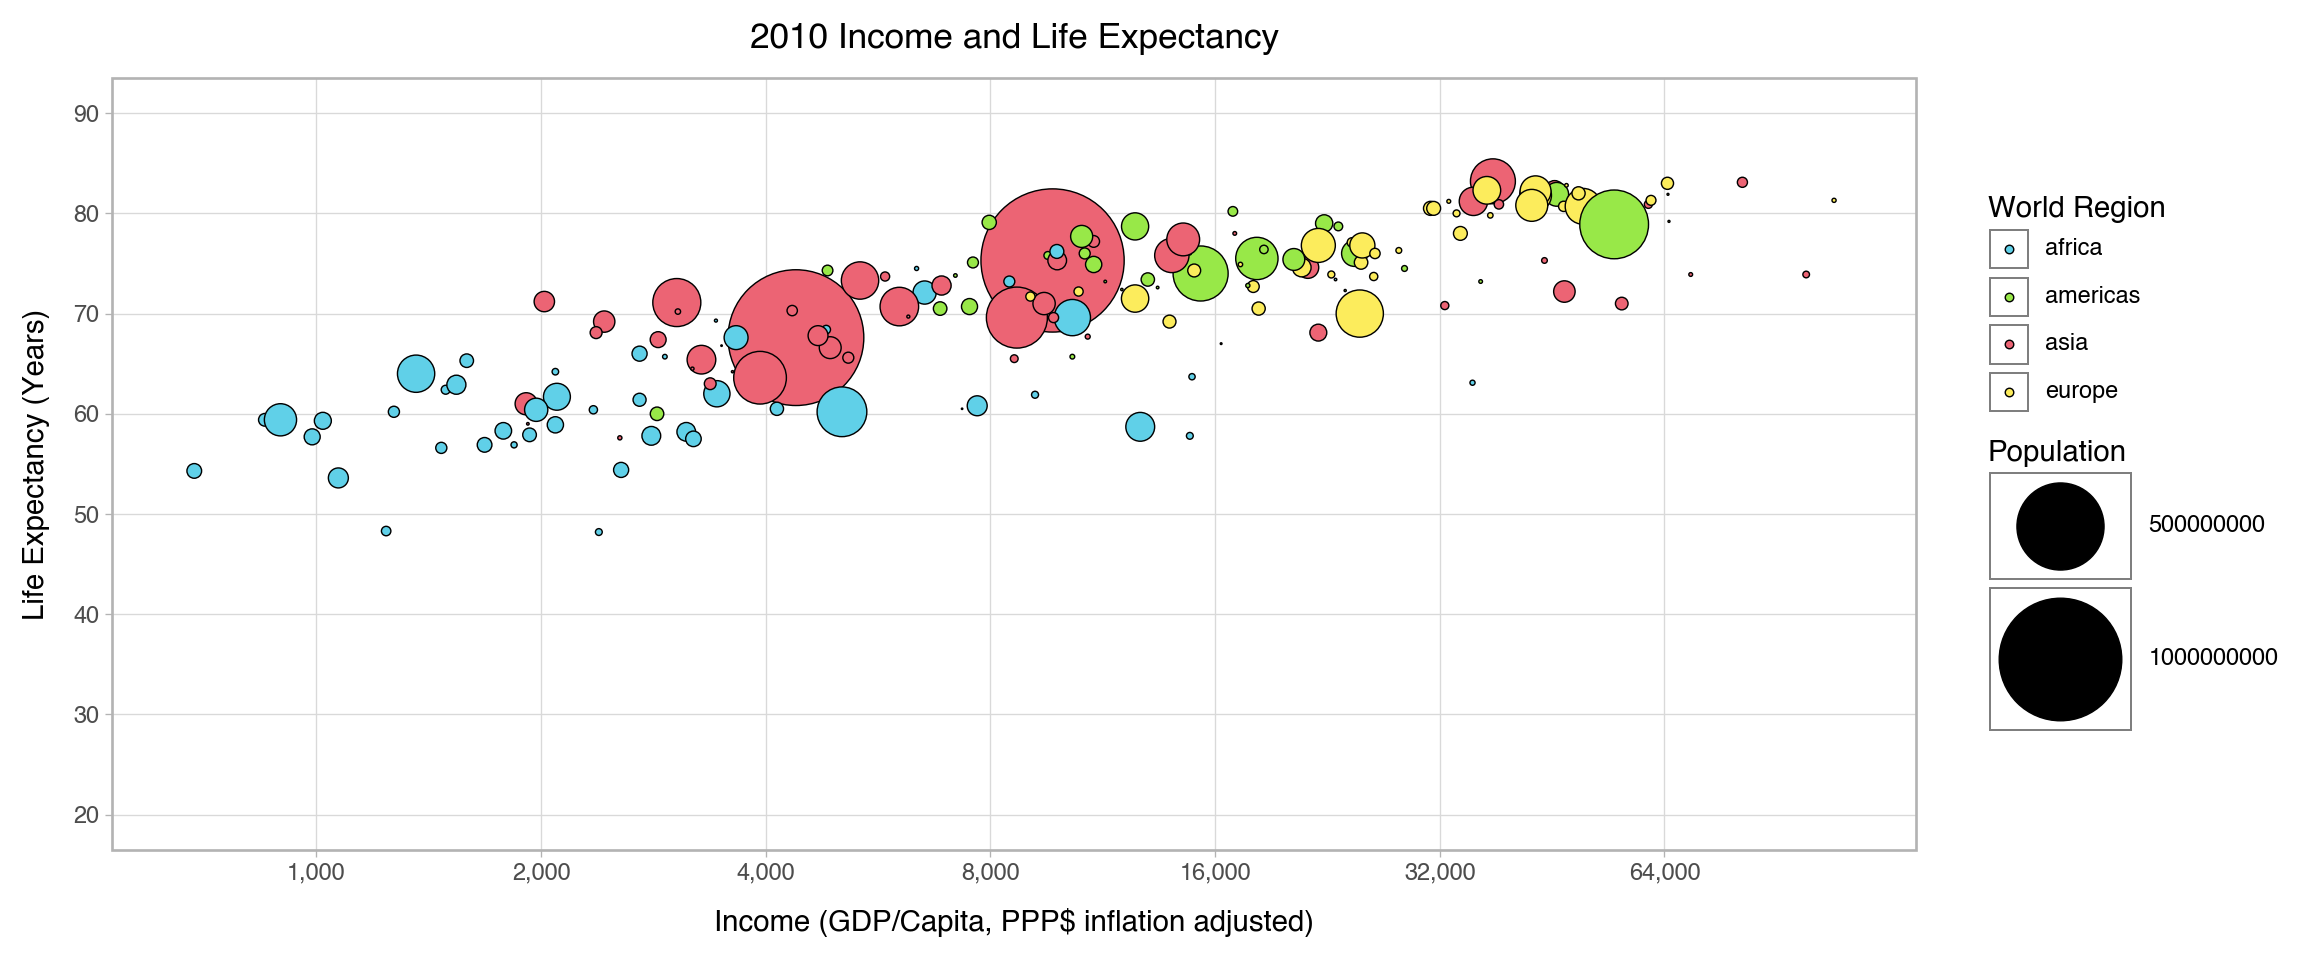

In [3]:
# Q1 - Scatterplot

from plotnine import ggplot, aes, geom_point, labs, theme_light, theme, element_blank, scale_x_log10, scale_y_continuous, scale_fill_manual, scale_size_area

# income is on the x-axis, life expectancy is on the y-axis, color shows the region, and size shows population

df_q1_clean = df_q1.dropna(
    subset=["income", "life_exp", "population", "four_regions"]
)

(
    ggplot(
        df_q1_clean,
        aes(
            x="income",
            y="life_exp",
            fill="four_regions",
            size="population"
        )
    )
    + geom_point(stroke=0.3)
    + scale_x_log10(
            breaks=[1000, 2000, 4000, 8000, 16000, 32000, 64000],
            labels=["1,000", "2,000", "4,000", "8,000",
            "16,000", "32,000", "64,000"]
)
    + scale_fill_manual(
        values={
            "africa": "#60D0E8",
            "americas": "#98E848",
            "asia": "#EC6474",
            "europe": "#FCEC5C"
        }
    )
    + scale_size_area(max_size=30)
    + labs(
        title="2010 Income and Life Expectancy",
        x="Income (GDP/Capita, PPP$ inflation adjusted)",
        y="Life Expectancy (Years)",
        color="World Region",
        size="Population",
        fill="World Region"
    )
    + scale_y_continuous(
        limits=(20, 90),
        breaks=range(20, 91, 10)
)
    + theme_light()
    + theme(figure_size=(12, 5), panel_grid_minor=element_blank())
)

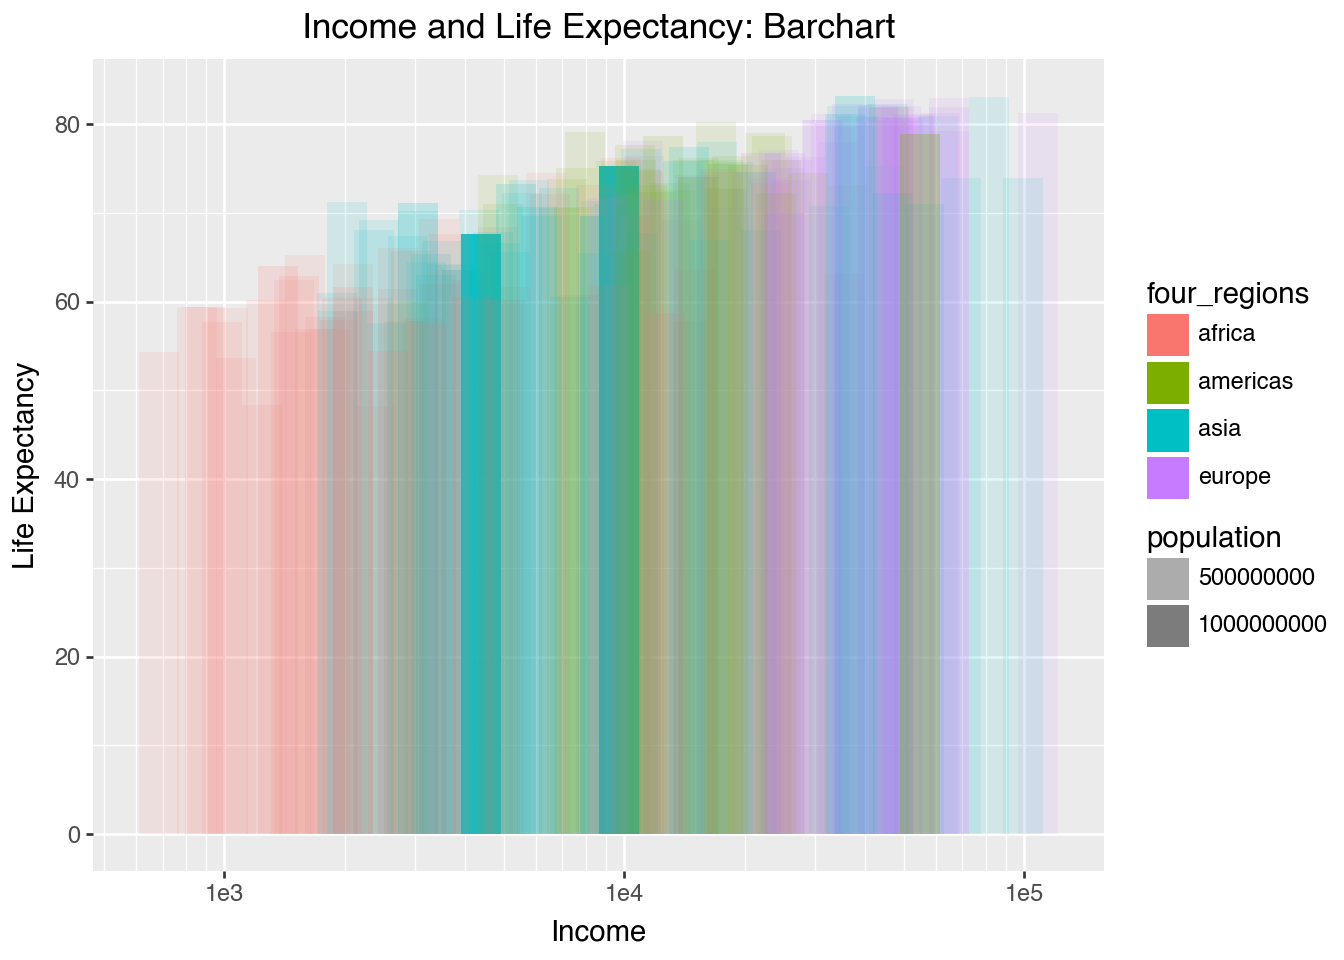

In [4]:
#Q1 - Barchart with geom_col()

from plotnine import ggplot, aes, geom_col, labs, scale_x_log10

(
    ggplot(
        df_q1_clean,
        aes(
            x="income",
            y="life_exp",
            fill="four_regions",
            alpha="population"
        )
    )
    + geom_col(
        position="identity",
        color=None,
        width=0.1
    )
    + scale_x_log10()
    + labs(
        title="Income and Life Expectancy: Barchart",
        x="Income",
        y="Life Expectancy"
    )

)

This plot uses bars to show life expectancy at different income levels. The colors show the world regions, and the transparency represents population. Though I think it is kind of unique and little interesting, this plot is not very effective because many of the bars overlap and are hard to compare.

In [5]:
df_q2 = pd.read_csv("../Data/Lab 1/q2data.csv")
df_q2.head()

,imports,exports,energy,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,NaN,NaN,NaN,1997,Afghanistan,asia,south_asia,asia_west,South Asia
1,36.7,11.5,427,1997,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,22.5,22.6,825,1997,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,NaN,NaN,1997,American Samoa,NaN,NaN,NaN,NaN
4,NaN,NaN,434,1997,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


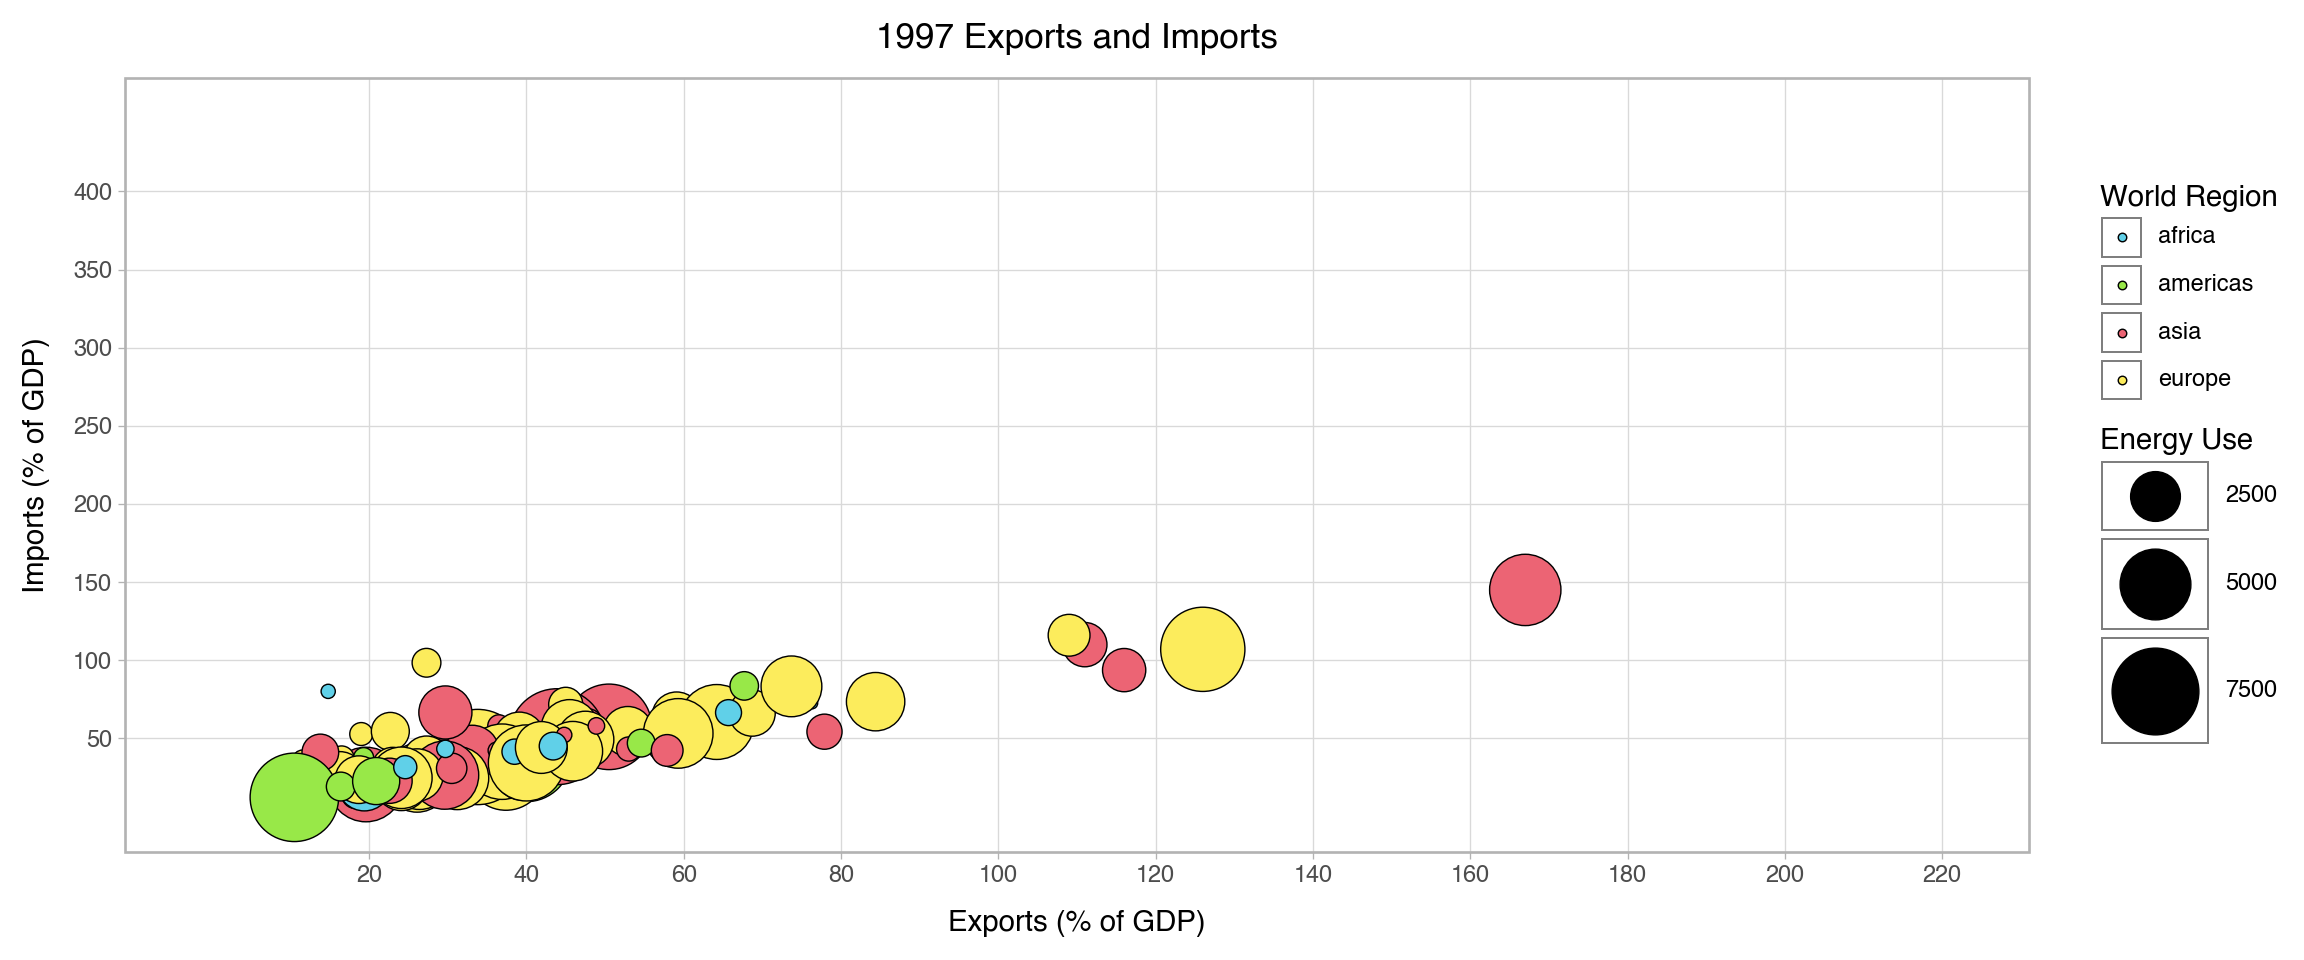

In [6]:
#Q2 - Scatterplot

import pandas as pd

from plotnine import (ggplot, aes, geom_point, labs, theme_light, theme, element_blank, scale_x_continuous, scale_y_continuous, scale_fill_manual, scale_size_area)

# exports are on the x-axis, imports are on the y-axis, color shows the region, and size shows energy use


df_q2["energy"] = pd.to_numeric(
    df_q2["energy"],
    errors="coerce"
)

df_q2_clean = df_q2.dropna(
    subset=["exports", "imports", "energy", "four_regions"]
)

(
    ggplot(
        df_q2_clean,
        aes(
            x="exports",
            y="imports",
            fill="four_regions",
            size="energy"
        )
    )
    + geom_point(stroke=0.3)
    + scale_x_continuous(
        limits=(0, 220),
        breaks=range(20, 221, 20)
    )
    + scale_y_continuous(
        limits=(0, 450),
        breaks=range(50, 401, 50)
    )
    + scale_fill_manual(
        values={
            "africa": "#60D0E8",
            "americas": "#98E848",
            "asia": "#EC6474",
            "europe": "#FCEC5C"
        }
    )
    + scale_size_area(max_size=20)
    + labs(
        title="1997 Exports and Imports",
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
        fill="World Region",
        size="Energy Use"
    )
    + theme_light()
    + theme(
        figure_size=(12, 5),
        panel_grid_minor=element_blank()
    )
)

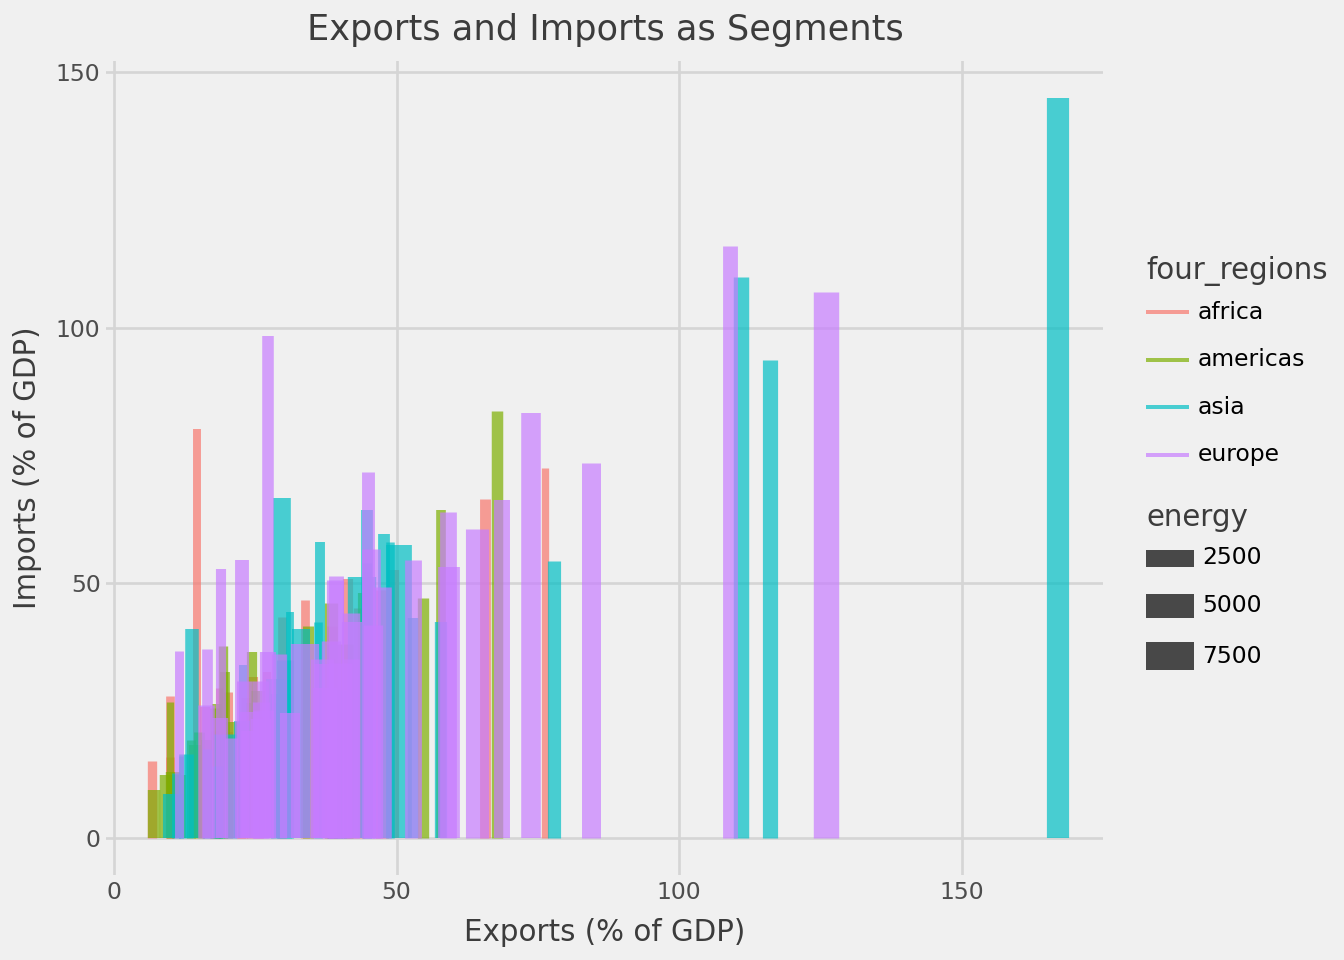

In [7]:
#Q2 - Segment plot with geom_segment()

from plotnine import ggplot, aes, geom_segment, labs, theme_538

(
    ggplot(
        df_q2_clean,
        aes(
            x="exports",
            xend="exports",
            y=0,
            yend="imports",
            color="four_regions",
            size="energy"
        )
    )
    + geom_segment(alpha=0.7)
    + labs(
        title="Exports and Imports as Segments",
        x="Exports (% of GDP)",
        y="Imports (% of GDP)"
    )
    + theme_538()
)

This plot uses vertical segments to show imports at each export level, where the colors represent world regions, and thicker lines represent more energy use. It shows how high imports are, but again, like the the barchart, many of the lines overlap, making individual countries difficult to see.

In [8]:
df_q3 = pd.read_csv("../Data/Lab 1/q3data.csv")
df_q3.head()

,internet_users,gdp,income,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,0.00456,330.0,1190.0,2001,Afghanistan,asia,south_asia,asia_west,South Asia
1,0.39000,2570.0,6780.0,2001,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,1.59000,3770.0,9230.0,2001,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,10500.0,NaN,2001,American Samoa,NaN,NaN,NaN,NaN
4,11.30000,42600.0,35600.0,2001,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia


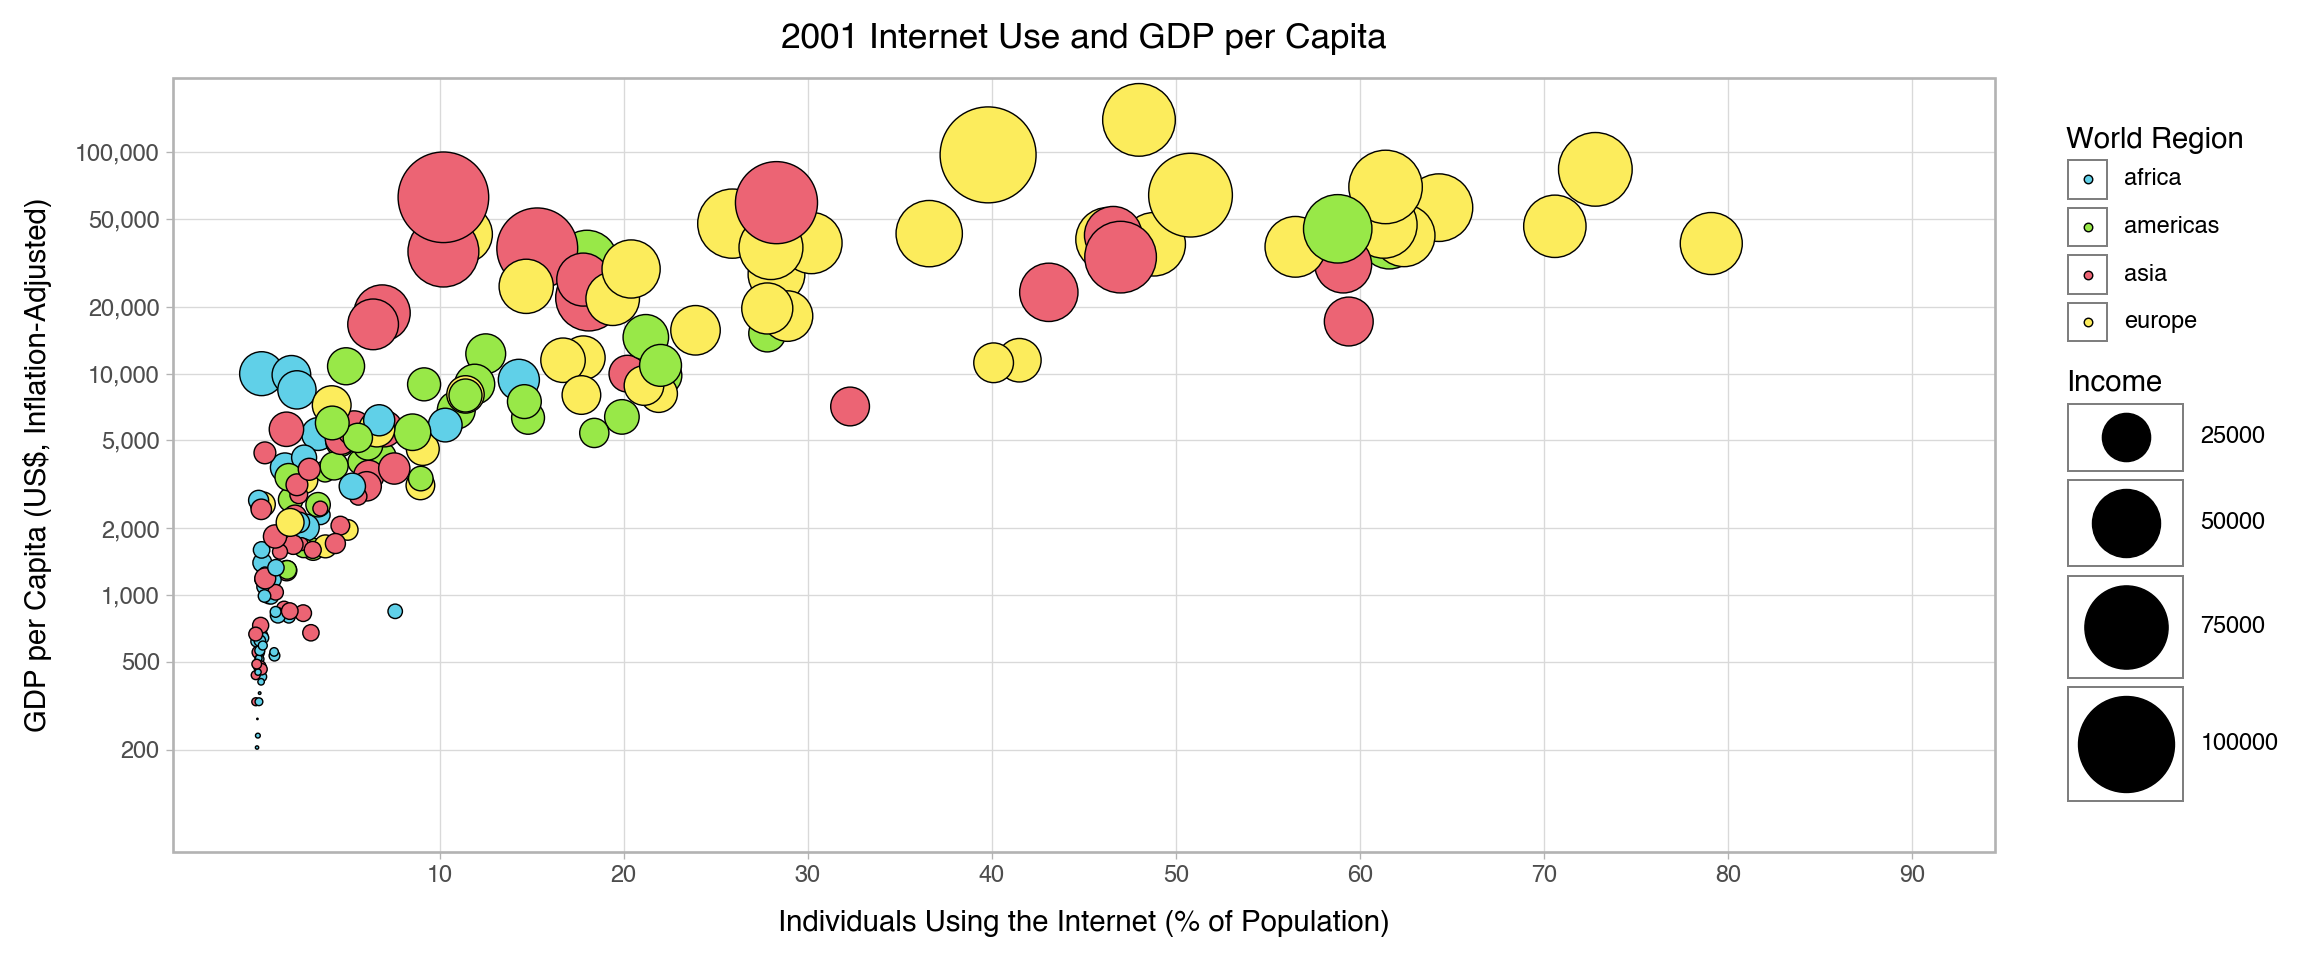

In [9]:
#Q3 - Scatterplot

import pandas as pd

from plotnine import ggplot, aes, geom_point, labs, theme_light, theme, element_blank, scale_x_continuous, scale_y_log10, scale_fill_manual, scale_size_area

# internet use is on the x-axis, gdp per capita is on the y-axis, color shows the region, and size shows income

df_q3_clean = df_q3.dropna(
    subset=["internet_users", "gdp", "income", "four_regions"]
)

(
    ggplot(
        df_q3_clean,
        aes(
            x="internet_users",
            y="gdp",
            fill="four_regions",
            size="income"
        )
    )
    + geom_point(stroke=0.3)
    + scale_x_continuous(
        limits=(0, 90),
        breaks=range(10, 91, 10)
    )
    + scale_y_log10(
        limits=(100, 150000),
        breaks=[
            200, 500, 1000, 2000, 5000,
            10000, 20000, 50000, 100000
        ],
        labels=[
            "200", "500", "1,000", "2,000", "5,000",
            "10,000", "20,000", "50,000", "100,000"
        ]
    )
    + scale_fill_manual(
        values={
            "africa": "#60D0E8",
            "americas": "#98E848",
            "asia": "#EC6474",
            "europe": "#FCEC5C"
        }
    )
    + scale_size_area(max_size=20)
    + labs(
        title="2001 Internet Use and GDP per Capita",
        x="Individuals Using the Internet (% of Population)",
        y="GDP per Capita (US$, Inflation-Adjusted)",
        fill="World Region",
        size="Income"
    )
    + theme_light()
    + theme(
        figure_size=(12, 5),
        panel_grid_minor=element_blank()
    )
)

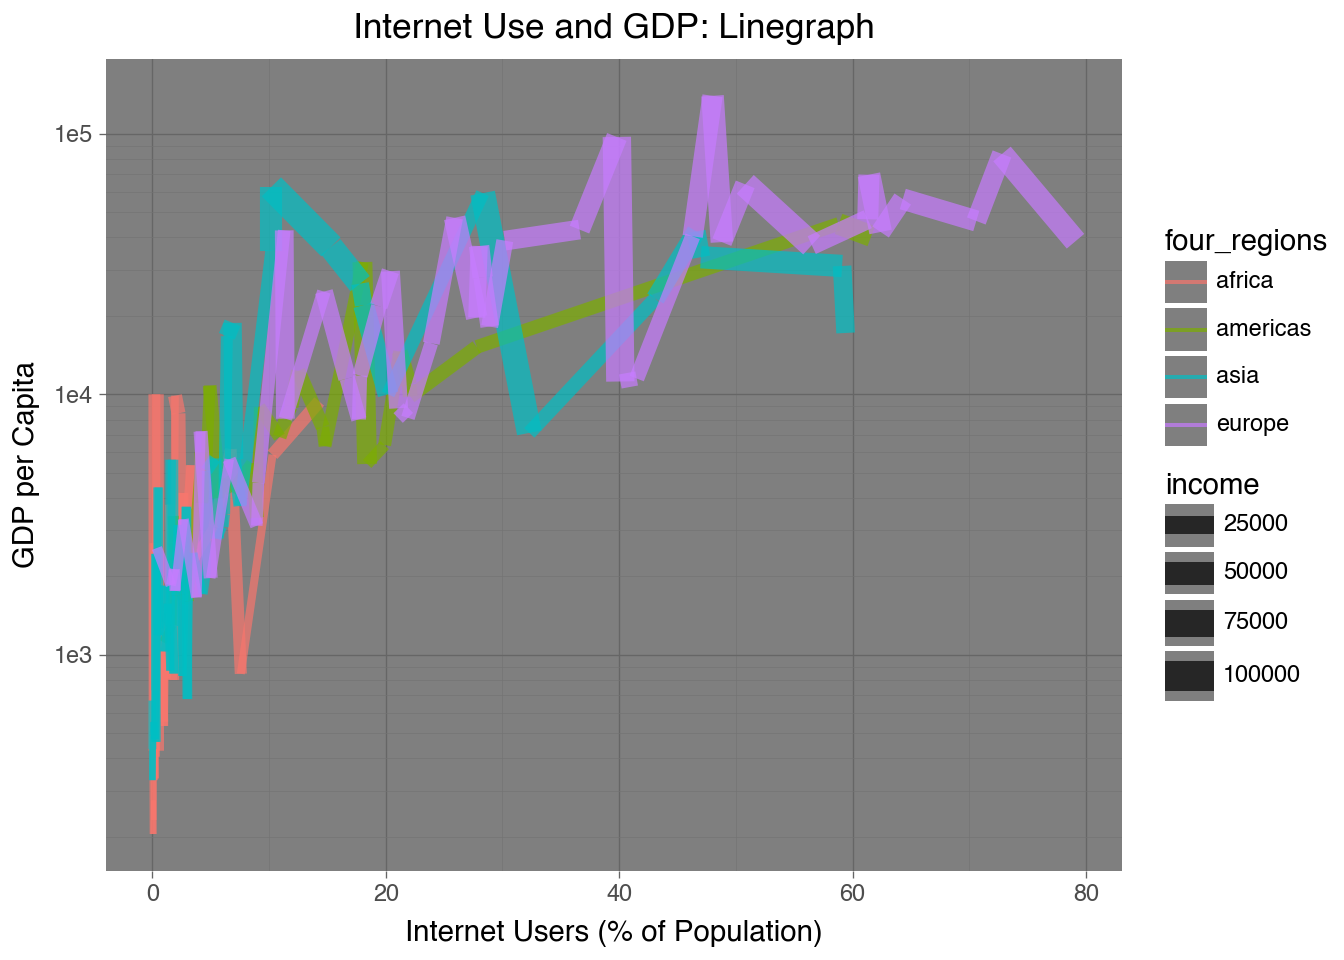

In [10]:
#Q3 Line chart with geom_line()

from plotnine import ggplot, aes, geom_line, labs, theme_dark, scale_y_log10

( ggplot(
        df_q3_clean,
        aes(
            x="internet_users",
            y="gdp",
            color="four_regions",
            group="four_regions",
            size="income"
        )
    )
    + geom_line(alpha=0.7)
    + scale_y_log10()
    + labs(
        title="Internet Use and GDP: Linegraph",
        x="Internet Users (% of Population)",
        y="GDP per Capita"
    )
    + theme_dark()
)

This alternative plot connects countries from the same world region with lines. Although its the most unique plot out of all the other, it is misleading because the countries are not part of a time sequence, but the lines make it look like they are connected in order.